In [1]:
# ============================================================
# CHECKPOINT 8 — Feature computation at scale
# Reads saved tensors from all 150 examples, builds graphs,
# computes spectral metrics, produces the consolidated
# per-example x per-layer feature table.
# No GPU needed -- pure numpy computation.
# ============================================================

In [2]:
# --- CELL 1: setup -- recreate DIRS, pull in generation+labeled data ---
import os, shutil

BASE_DIR = "/kaggle/working/spectral_v2"
DIRS = {
    "generations": f"{BASE_DIR}/generations",
    "extractions": f"{BASE_DIR}/extractions",
    "features":    f"{BASE_DIR}/features",
    "results":     f"{BASE_DIR}/results",
    "logs":        f"{BASE_DIR}/logs",
}
for d in DIRS.values():
    os.makedirs(d, exist_ok=True)

GSM8K_DIR = f"{DIRS['generations']}/gsm8k"

# If GSM8K_DIR is empty, pull from the Analysis notebook's saved output
# (adjust this path to match your latest Analysis notebook's output slug)
if not os.path.exists(GSM8K_DIR) or len(os.listdir(GSM8K_DIR)) == 0:
    SOURCE = "/kaggle/input/notebooks/aishidev/final-spectral-research-project-analysis/spectral_v2"
    shutil.copytree(SOURCE, BASE_DIR, dirs_exist_ok=True)

print("GSM8K files:", len(os.listdir(GSM8K_DIR)))
assert len(os.listdir(GSM8K_DIR)) == 300, "STOP: expected 300 files (150 json + 150 npz)."

GSM8K files: 300


In [3]:
# --- CELL 2: graph-building function (numpy version of Checkpoint 4) ---
import numpy as np

def build_layer_graphs_np(attentions, eps=1e-8):
    """
    attentions: numpy array [layers, heads, seq, seq] (loaded from .npz)
    Returns a list of dicts, one per layer, each with L (combinatorial Laplacian)
    and L_sym (normalized Laplacian).
    """
    n_layers = attentions.shape[0]
    layer_graphs = []

    for l in range(n_layers):
        A = attentions[l].astype(np.float64)  # [heads, seq, seq]
        heads, seq, _ = A.shape

        W_per_head = 0.5 * (A + A.transpose(0, 2, 1))
        head_mass = W_per_head.sum(axis=(1, 2))
        head_weights = head_mass / (head_mass.sum() + eps)
        W = np.tensordot(head_weights, W_per_head, axes=(0, 0))

        D = np.diag(W.sum(axis=1))
        L = D - W

        d = W.sum(axis=1)
        d_inv_sqrt = np.where(d > eps, 1.0 / np.sqrt(d + eps), 0.0)
        D_inv_sqrt = np.diag(d_inv_sqrt)
        L_sym = np.eye(seq) - D_inv_sqrt @ W @ D_inv_sqrt

        layer_graphs.append({"layer": l, "L": L, "L_sym": L_sym})

    return layer_graphs

In [4]:
# --- CELL 3: spectral metrics function (numpy version of Checkpoint 5) ---
def compute_spectral_metrics_np(L, hidden_state, eps=1e-10):
    n = L.shape[0]
    eigvals, eigvecs = np.linalg.eigh(L)
    eigvals = np.clip(eigvals, 0, None)

    fiedler = eigvals[1] if n > 1 else 0.0

    eigval_sum = eigvals.sum()
    if eigval_sum > eps:
        p = eigvals / eigval_sum
        p_nonzero = p[p > eps]
        spectral_entropy = -np.sum(p_nonzero * np.log(p_nonzero))
        spectral_entropy = spectral_entropy / np.log(n) if n > 1 else 0.0
    else:
        spectral_entropy = 0.0

    x = hidden_state.astype(np.float64)
    signal = np.linalg.norm(x, axis=1)
    signal = (signal - signal.mean()) / (signal.std() + eps)

    dirichlet_energy = float(signal @ L @ signal)

    signal_proj = eigvecs.T @ signal
    energy = signal_proj ** 2
    total_energy = energy.sum()
    cutoff_idx = n // 2
    hfer = float(energy[cutoff_idx:].sum() / (total_energy + eps))

    smoothness = float(1.0 / (1.0 + dirichlet_energy))
    return {
        "fiedler": float(fiedler),
        "spectral_entropy": float(spectral_entropy),
        "hfer": hfer,
        "smoothness": smoothness,
        "dirichlet_energy": dirichlet_energy,
    }

In [5]:
# --- CELL 4: run across all 150 examples, build the consolidated table ---
import json
import pandas as pd

all_rows = []
failed_examples = []

json_files = [f for f in os.listdir(GSM8K_DIR) if f.endswith(".json")]
print(f"Processing {len(json_files)} examples...")

for i, fname in enumerate(json_files):
    example_id = fname.replace(".json", "")
    json_path = f"{GSM8K_DIR}/{fname}"
    npz_path = f"{GSM8K_DIR}/{example_id}_tensors.npz"

    try:
        with open(json_path) as f:
            record = json.load(f)

        tensors = np.load(npz_path)
        attentions = tensors["attentions"]      # [layers, heads, seq, seq]
        hidden_states = tensors["hidden_states"]  # [layers+1, seq, d_model]

        layer_graphs = build_layer_graphs_np(attentions)

        for lg in layer_graphs:
            layer_idx = lg["layer"]
            hs = hidden_states[layer_idx]  # hidden state entering this layer
            metrics = compute_spectral_metrics_np(lg["L"], hs)
            row = {
                "example_id": example_id,
                "layer": layer_idx,
                "is_correct": record["is_correct"],
                "response_len": record["response_len"],
                "prompt_len": record["prompt_len"],
                "total_len": record["total_len"],
                **metrics,
            }
            all_rows.append(row)

        if (i + 1) % 25 == 0:
            print(f"  [{i+1}/{len(json_files)}] processed")

    except Exception as e:
        failed_examples.append((example_id, str(e)))
        print(f"FAILED on {example_id}: {e}")
        continue

print(f"\nDone. {len(json_files) - len(failed_examples)} examples processed successfully, "
      f"{len(failed_examples)} failed.")

Processing 150 examples...
  [25/150] processed
  [50/150] processed
  [75/150] processed
  [100/150] processed
  [125/150] processed
  [150/150] processed

Done. 150 examples processed successfully, 0 failed.


In [6]:
# --- CELL 5: save the consolidated feature table ---
features_df = pd.DataFrame(all_rows)
print(f"\nFeature table shape: {features_df.shape}")
print(f"Expected: {len(json_files) - len(failed_examples)} examples x 24 layers = "
      f"{(len(json_files) - len(failed_examples)) * 24} rows")

assert features_df.shape[0] == (len(json_files) - len(failed_examples)) * 24, \
    "STOP: row count doesn't match expected examples x 24 layers."

output_path = f"{DIRS['features']}/metrics_per_example_layer_gsm8k.csv"
features_df.to_csv(output_path, index=False)
print(f"\nSaved: {output_path}")
print(features_df.head(10))

# --- CELL 6: quick sanity checks on the full table ---
print(f"\nCorrect examples: {(features_df.groupby('example_id')['is_correct'].first() == True).sum()}")
print(f"Incorrect examples: {(features_df.groupby('example_id')['is_correct'].first() == False).sum()}")
print(f"\nAny NaNs in metrics?")
print(features_df[["fiedler", "spectral_entropy", "hfer", "smoothness", "dirichlet_energy"]].isna().sum())

print("\n>>> Save & Run All once this looks correct. <<<")


Feature table shape: (3600, 11)
Expected: 150 examples x 24 layers = 3600 rows

Saved: /kaggle/working/spectral_v2/features/metrics_per_example_layer_gsm8k.csv
     example_id  layer  is_correct  response_len  prompt_len  total_len  \
0  0e15d21591ac      0       False           282          88        370   
1  0e15d21591ac      1       False           282          88        370   
2  0e15d21591ac      2       False           282          88        370   
3  0e15d21591ac      3       False           282          88        370   
4  0e15d21591ac      4       False           282          88        370   
5  0e15d21591ac      5       False           282          88        370   
6  0e15d21591ac      6       False           282          88        370   
7  0e15d21591ac      7       False           282          88        370   
8  0e15d21591ac      8       False           282          88        370   
9  0e15d21591ac      9       False           282          88        370   

    fiedler  

In [7]:
# ============================================================
# CHECKPOINT 9 — Plots and confound diagnostics (FINAL)
# Reads the Checkpoint 8 feature table, produces trajectory
# plots, threshold-based effect visualization, and matching
# confound checks. No GPU needed.
# ============================================================

In [8]:
import shutil

SOURCE = "/kaggle/input/notebooks/aishidev/final-spectral-research-project-features/spectral_v2"
shutil.copytree(SOURCE, BASE_DIR, dirs_exist_ok=True)

print("Copied.")
print(os.path.exists(f"{DIRS['features']}/metrics_per_example_layer_gsm8k.csv"))

Copied.
True


In [9]:
# --- CELL 1: setup -- load the feature table ---
import os, shutil

BASE_DIR = "/kaggle/working/spectral_v2"
DIRS = {
    "generations": f"{BASE_DIR}/generations",
    "extractions": f"{BASE_DIR}/extractions",
    "features":    f"{BASE_DIR}/features",
    "results":     f"{BASE_DIR}/results",
    "logs":        f"{BASE_DIR}/logs",
}
for d in DIRS.values():
    os.makedirs(d, exist_ok=True)

FEATURES_PATH = f"{DIRS['features']}/metrics_per_example_layer_gsm8k.csv"

if not os.path.exists(FEATURES_PATH):
    SOURCE = "/kaggle/input/notebooks/aishidev/final-spectral-research-project-analysis/spectral_v2"
    shutil.copytree(SOURCE, BASE_DIR, dirs_exist_ok=True)

import pandas as pd
df = pd.read_csv(FEATURES_PATH)
print(f"Loaded feature table: {df.shape}")
print(df.head())

METRICS = ["fiedler", "spectral_entropy", "hfer", "smoothness"]

Loaded feature table: (3600, 11)
     example_id  layer  is_correct  response_len  prompt_len  total_len  \
0  316eac029fc3      0        True           403          87        490   
1  316eac029fc3      1        True           403          87        490   
2  316eac029fc3      2        True           403          87        490   
3  316eac029fc3      3        True           403          87        490   
4  316eac029fc3      4        True           403          87        490   

    fiedler  spectral_entropy      hfer  smoothness  dirichlet_energy  
0  0.230262          0.990199  0.476172    0.002178        458.083604  
1  0.186753          0.984150  0.333663    0.002709        368.142317  
2  0.111153          0.980156  0.257849    0.002963        336.470175  
3  0.295450          0.846022  0.999353    0.000019      52692.259888  
4  0.286518          0.871791  0.999652    0.000024      42276.513658  


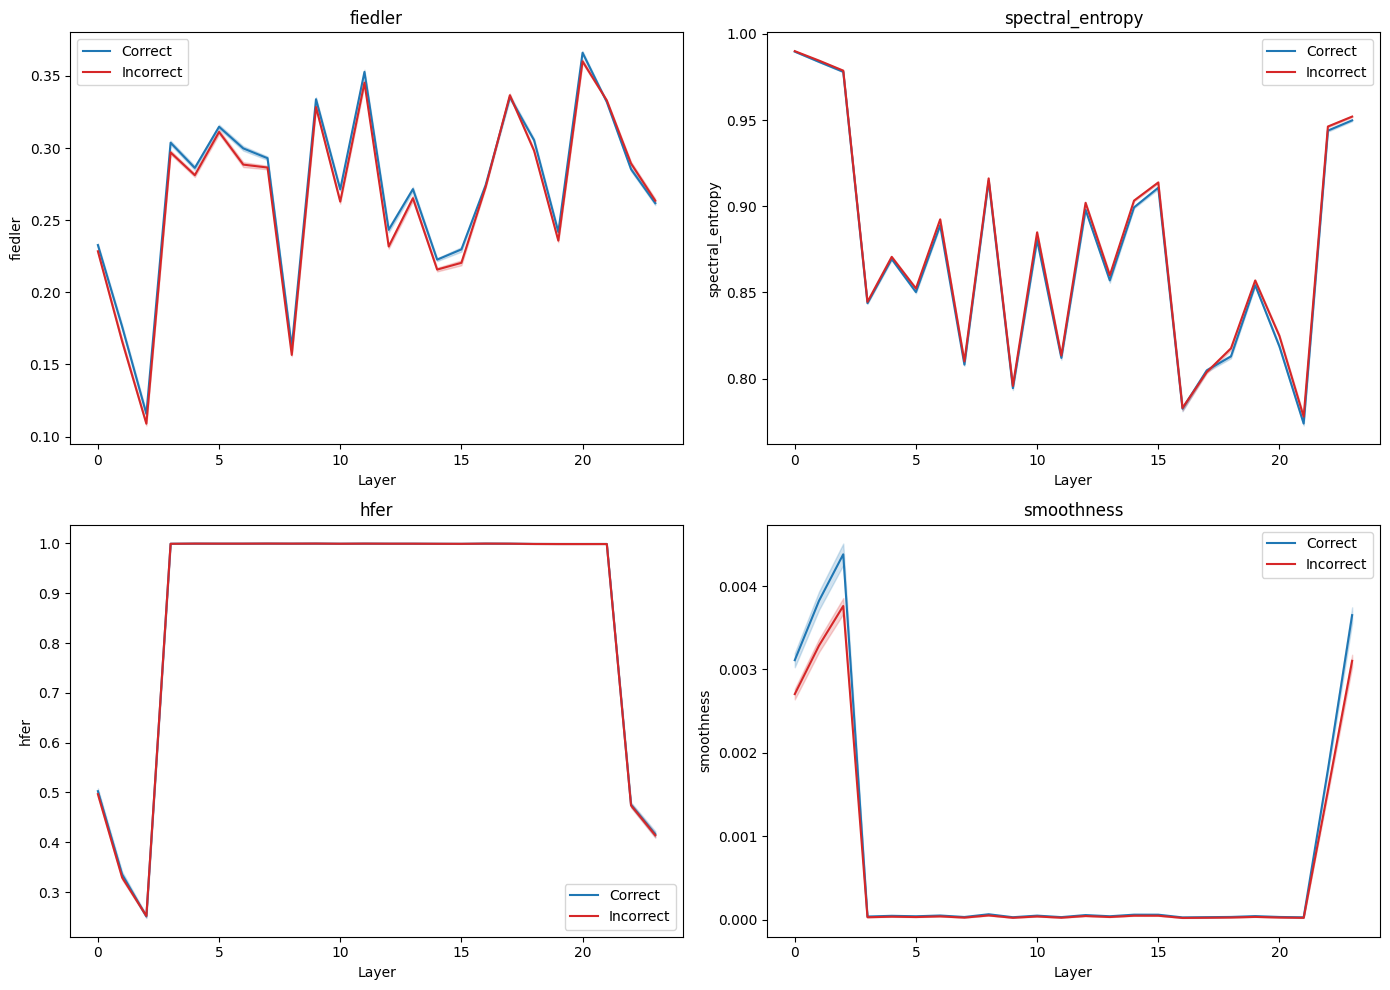

Saved: /kaggle/working/spectral_v2/results/gsm8k_trajectory_plots.png


In [10]:
# --- CELL 2: trajectory plots -- mean per layer, correct vs incorrect ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, metric in enumerate(METRICS):
    ax = axes[i]
    for label, group_name, color in [(True, "Correct", "tab:blue"), (False, "Incorrect", "tab:red")]:
        subset = df[df["is_correct"] == label]
        layer_means = subset.groupby("layer")[metric].mean()
        layer_sems = subset.groupby("layer")[metric].sem()
        ax.plot(layer_means.index, layer_means.values, label=group_name, color=color)
        ax.fill_between(layer_means.index,
                         layer_means.values - layer_sems.values,
                         layer_means.values + layer_sems.values,
                         alpha=0.2, color=color)
    ax.set_title(metric)
    ax.set_xlabel("Layer")
    ax.set_ylabel(metric)
    ax.legend()

plt.tight_layout()
plot_path = f"{DIRS['results']}/gsm8k_trajectory_plots.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Saved: {plot_path}")

In [11]:
# --- CELL 3: per-layer effect sizes (Cohen's d) for all metrics ---
import numpy as np

def cohens_d(a, b):
    n1, n2 = len(a), len(b)
    pooled_std = np.sqrt(((n1-1)*a.std(ddof=1)**2 + (n2-1)*b.std(ddof=1)**2) / (n1+n2-2))
    if pooled_std == 0:
        return 0.0
    return (a.mean() - b.mean()) / pooled_std

effect_rows = []
for metric in METRICS:
    for layer in sorted(df["layer"].unique()):
        layer_df = df[df["layer"] == layer]
        correct_vals = layer_df[layer_df["is_correct"] == True][metric]
        incorrect_vals = layer_df[layer_df["is_correct"] == False][metric]
        d = cohens_d(correct_vals, incorrect_vals)
        effect_rows.append({"metric": metric, "layer": layer, "cohens_d": d})

effects_df = pd.DataFrame(effect_rows)
effects_df["abs_d"] = effects_df["cohens_d"].abs()
top_effects = effects_df.sort_values("abs_d", ascending=False).head(10)
print("Top 10 largest raw effect sizes (layer x metric combinations):")
print(top_effects[["metric", "layer", "cohens_d"]])

effects_path = f"{DIRS['results']}/gsm8k_raw_effect_sizes.csv"
effects_df.to_csv(effects_path, index=False)
print(f"\nSaved: {effects_path}")

Top 10 largest raw effect sizes (layer x metric combinations):
              metric  layer  cohens_d
38  spectral_entropy     14 -0.879651
12           fiedler     12  0.831432
36  spectral_entropy     12 -0.799837
6            fiedler      6  0.780290
30  spectral_entropy      6 -0.778371
44  spectral_entropy     20 -0.776976
95        smoothness     23  0.771878
34  spectral_entropy     10 -0.746168
10           fiedler     10  0.734735
25  spectral_entropy      1 -0.706675

Saved: /kaggle/working/spectral_v2/results/gsm8k_raw_effect_sizes.csv



fiedler: 13 layer(s) with |d| >= 0.5


/tmp/ipykernel_16/590954083.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes_flat[i].boxplot(data_to_plot, labels=["Correct", "Incorrect"])
/tmp/ipykernel_16/590954083.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes_flat[i].boxplot(data_to_plot, labels=["Correct", "Incorrect"])
/tmp/ipykernel_16/590954083.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes_flat[i].boxplot(data_to_plot, labels=["Correct", "Incorrect"])
/tmp/ipykernel_16/590954083.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name

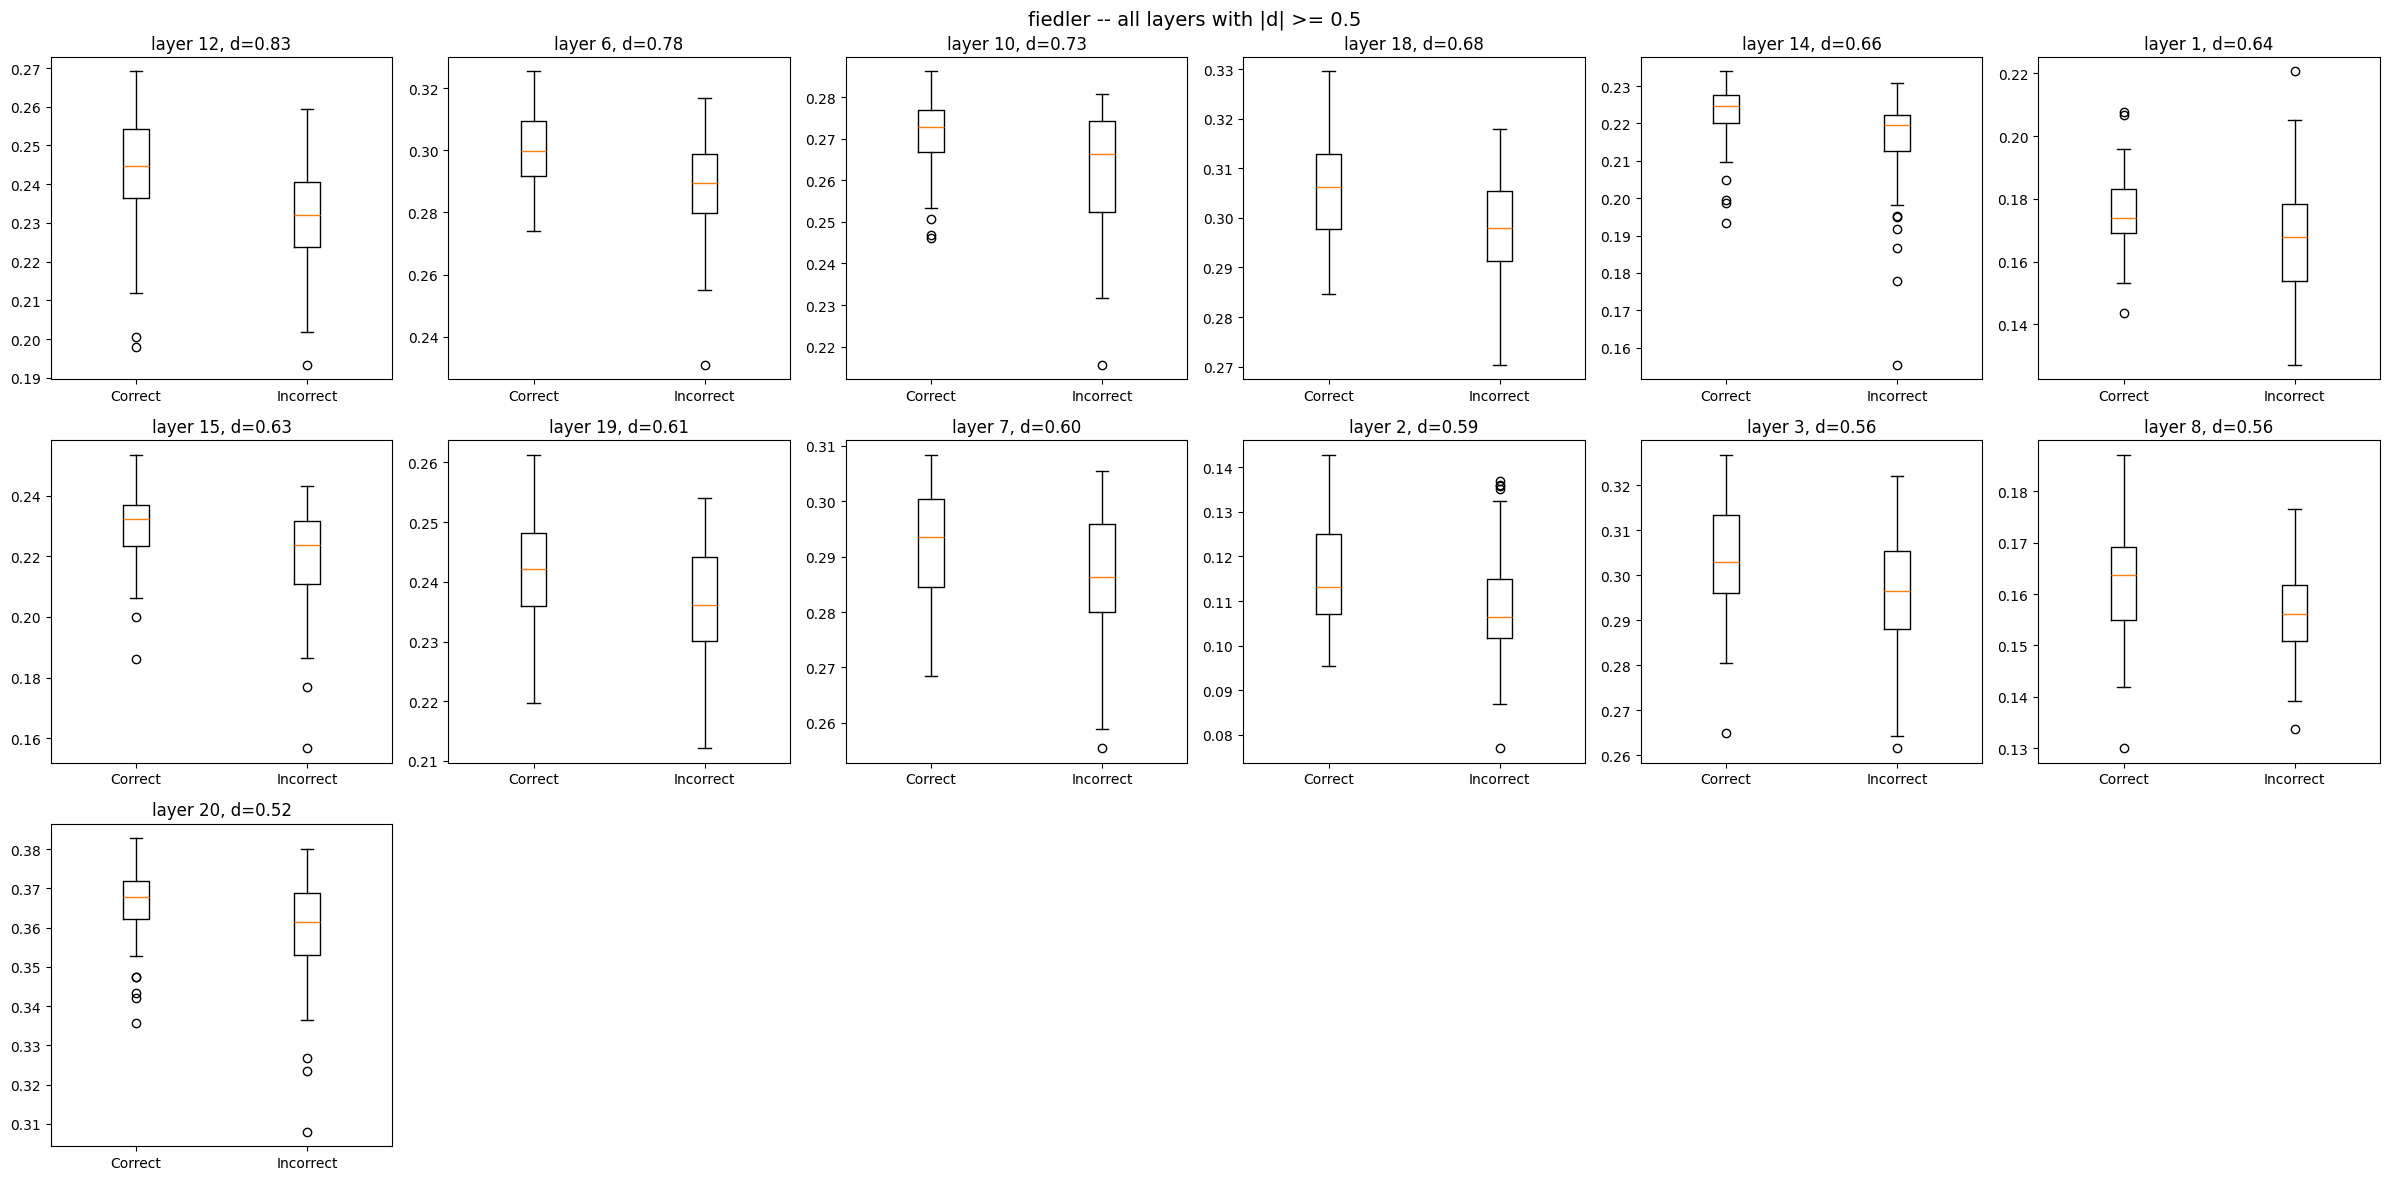

  Saved: /kaggle/working/spectral_v2/results/gsm8k_zoomed_boxplots_fiedler.png

spectral_entropy: 12 layer(s) with |d| >= 0.5


/tmp/ipykernel_16/590954083.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes_flat[i].boxplot(data_to_plot, labels=["Correct", "Incorrect"])
/tmp/ipykernel_16/590954083.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes_flat[i].boxplot(data_to_plot, labels=["Correct", "Incorrect"])
/tmp/ipykernel_16/590954083.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes_flat[i].boxplot(data_to_plot, labels=["Correct", "Incorrect"])
/tmp/ipykernel_16/590954083.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name

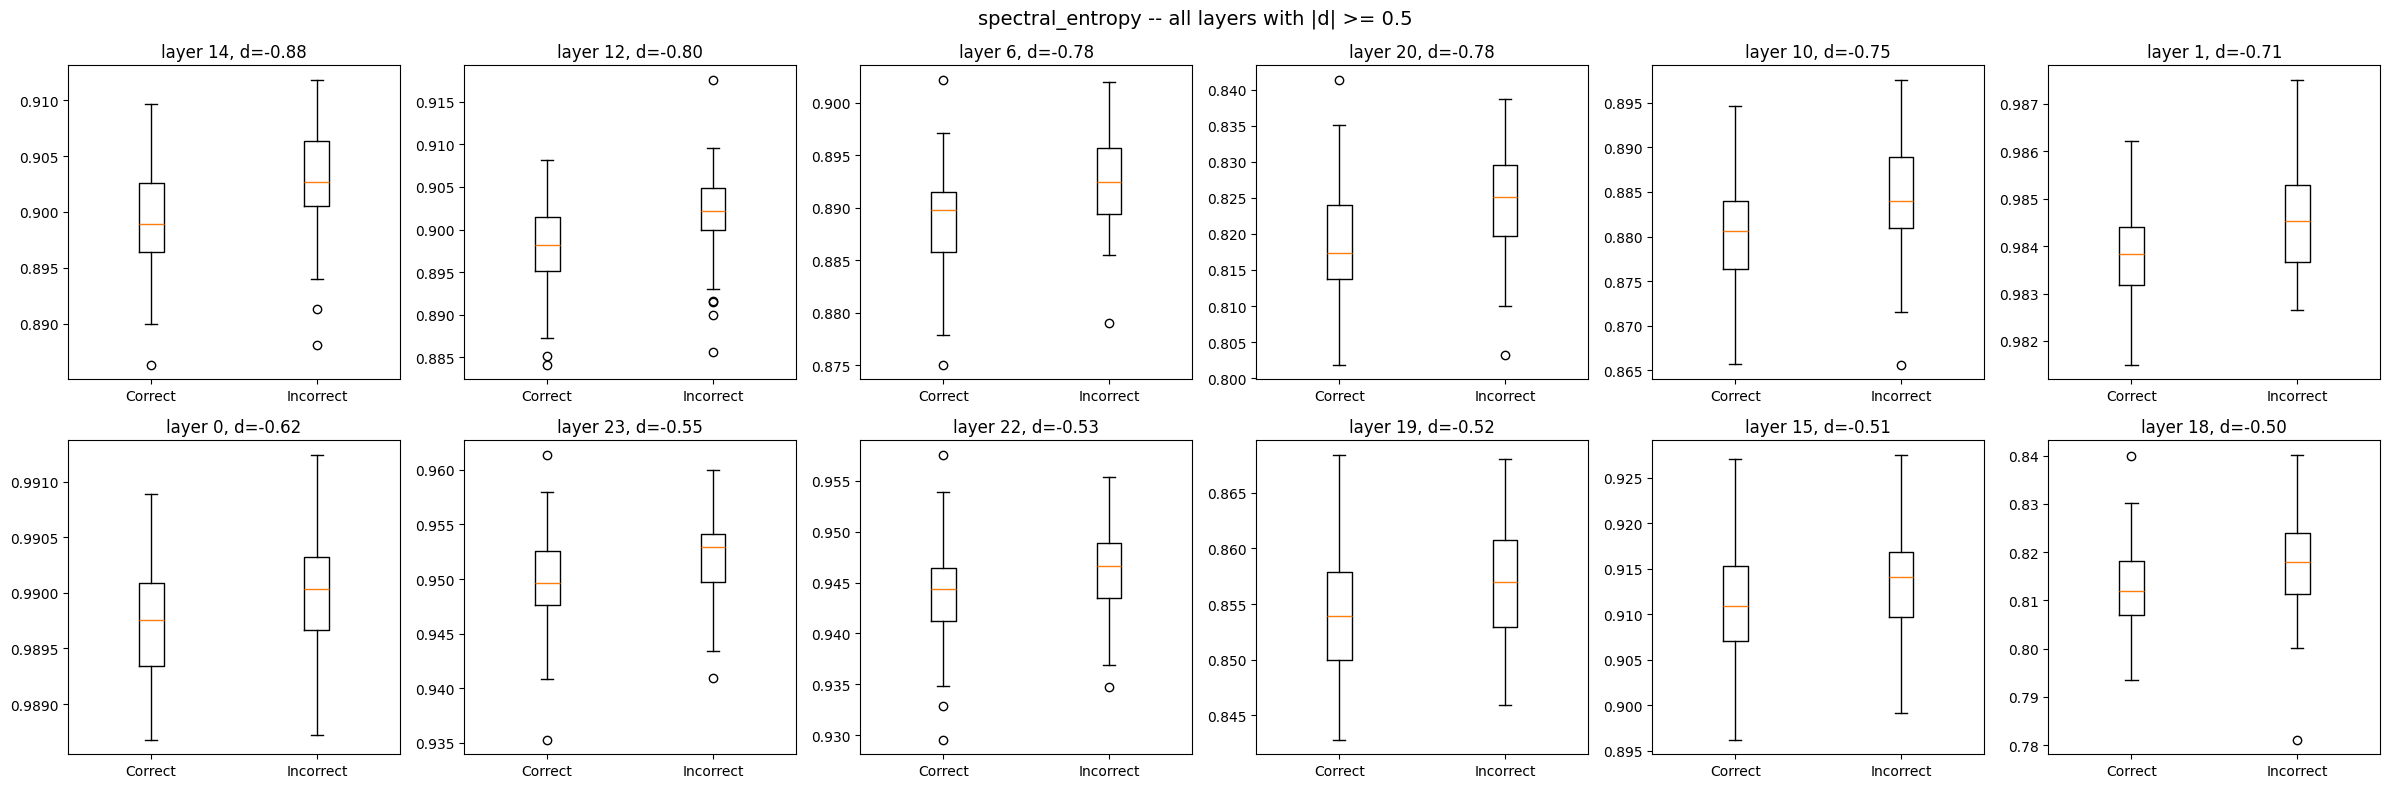

  Saved: /kaggle/working/spectral_v2/results/gsm8k_zoomed_boxplots_spectral_entropy.png

hfer: 3 layer(s) with |d| >= 0.5


/tmp/ipykernel_16/590954083.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes_flat[i].boxplot(data_to_plot, labels=["Correct", "Incorrect"])
/tmp/ipykernel_16/590954083.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes_flat[i].boxplot(data_to_plot, labels=["Correct", "Incorrect"])
/tmp/ipykernel_16/590954083.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes_flat[i].boxplot(data_to_plot, labels=["Correct", "Incorrect"])


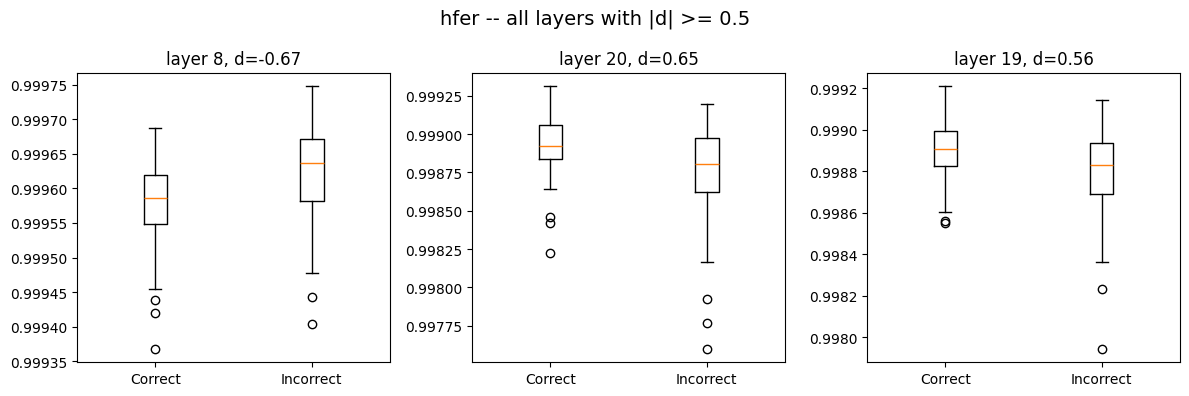

  Saved: /kaggle/working/spectral_v2/results/gsm8k_zoomed_boxplots_hfer.png

smoothness: 24 layer(s) with |d| >= 0.5


/tmp/ipykernel_16/590954083.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes_flat[i].boxplot(data_to_plot, labels=["Correct", "Incorrect"])
/tmp/ipykernel_16/590954083.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes_flat[i].boxplot(data_to_plot, labels=["Correct", "Incorrect"])
/tmp/ipykernel_16/590954083.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes_flat[i].boxplot(data_to_plot, labels=["Correct", "Incorrect"])
/tmp/ipykernel_16/590954083.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name

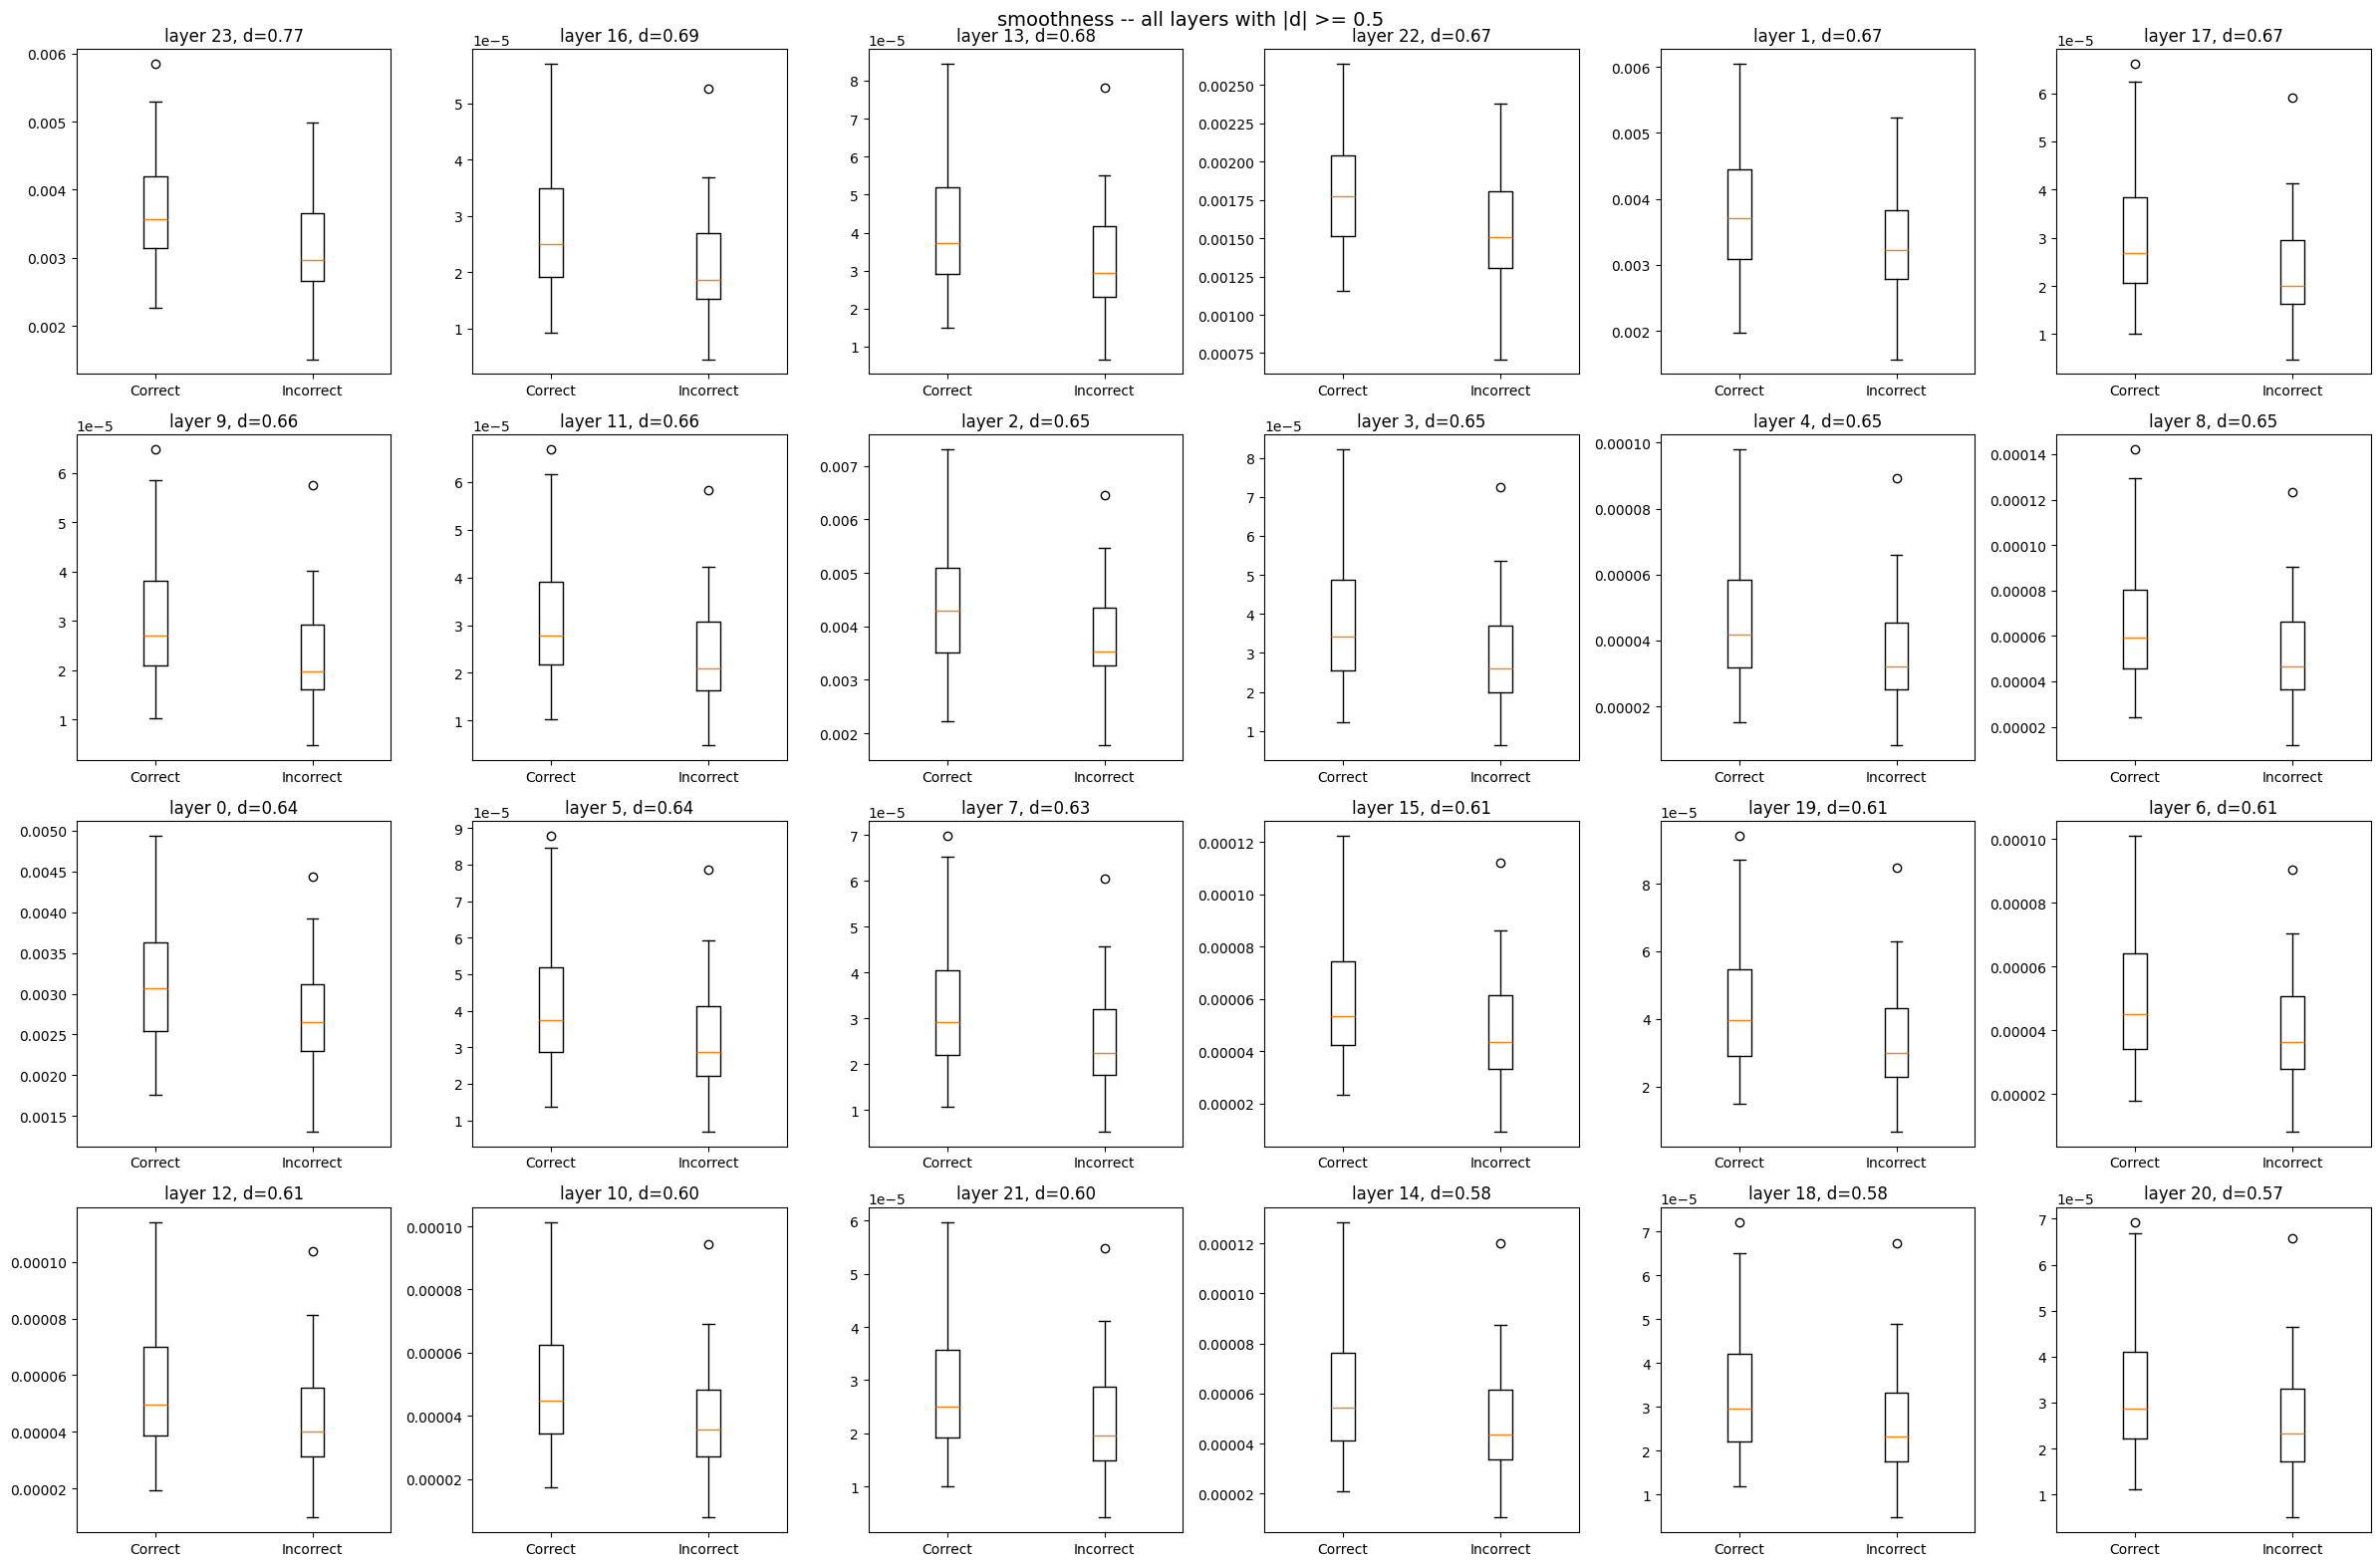

  Saved: /kaggle/working/spectral_v2/results/gsm8k_zoomed_boxplots_smoothness.png

>>> Threshold used: |Cohen's d| >= 0.5. This is a raw/uncorrected screen -- 
>>> formal significance with BH correction comes in Research Step 8, not here. <<<


In [12]:
# --- CELL 4: zoomed boxplots for EVERY layer clearing a meaningful effect-size threshold ---
EFFECT_THRESHOLD = 0.5

for metric in METRICS:
    metric_effects = effects_df[effects_df["metric"] == metric].sort_values("abs_d", ascending=False)
    qualifying_layers = metric_effects[metric_effects["abs_d"] >= EFFECT_THRESHOLD]

    n_qualifying = len(qualifying_layers)
    print(f"\n{metric}: {n_qualifying} layer(s) with |d| >= {EFFECT_THRESHOLD}")

    if n_qualifying == 0:
        print(f"  No layers clear the threshold for {metric} -- skipping plot.")
        continue

    n_cols = min(n_qualifying, 6)
    n_rows = int(np.ceil(n_qualifying / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), squeeze=False)
    axes_flat = axes.flatten()

    for i, (_, effect_row) in enumerate(qualifying_layers.iterrows()):
        layer = int(effect_row["layer"])
        d_val = effect_row["cohens_d"]

        layer_df = df[df["layer"] == layer]
        data_to_plot = [
            layer_df[layer_df["is_correct"] == True][metric].values,
            layer_df[layer_df["is_correct"] == False][metric].values,
        ]
        axes_flat[i].boxplot(data_to_plot, labels=["Correct", "Incorrect"])
        axes_flat[i].set_title(f"layer {layer}, d={d_val:.2f}")
        
    for j in range(n_qualifying, len(axes_flat)):
        axes_flat[j].axis("off")

    fig.suptitle(f"{metric} -- all layers with |d| >= {EFFECT_THRESHOLD}", fontsize=14)
    plt.tight_layout()
    zoom_path = f"{DIRS['results']}/gsm8k_zoomed_boxplots_{metric}.png"
    plt.savefig(zoom_path, dpi=150)
    plt.show()
    print(f"  Saved: {zoom_path}")

print(f"\n>>> Threshold used: |Cohen's d| >= {EFFECT_THRESHOLD}. This is a raw/uncorrected screen -- ")
print(">>> formal significance with BH correction comes in Research Step 8, not here. <<<")

In [13]:
# --- CELL 5: length confound check at EVERY layer clearing the SAME threshold as Cell 4 ---
from scipy import stats

print("\nResponse length by correctness (example-level, not per-layer):")
example_level = df.drop_duplicates("example_id")[["example_id", "is_correct", "response_len"]]
print(example_level.groupby("is_correct")["response_len"].describe())

length_t, length_p = stats.ttest_ind(
    example_level[example_level["is_correct"] == True]["response_len"],
    example_level[example_level["is_correct"] == False]["response_len"],
)
print(f"\nLength difference t-test (correct vs incorrect groups): t={length_t:.3f}, p={length_p:.4f}")

print(f"\nCorrelation between response_len and each metric, at every layer with |d| >= {EFFECT_THRESHOLD}:")
confound_rows = []

for metric in METRICS:
    metric_effects = effects_df[effects_df["metric"] == metric].sort_values("abs_d", ascending=False)
    qualifying_layers = metric_effects[metric_effects["abs_d"] >= EFFECT_THRESHOLD]

    if len(qualifying_layers) == 0:
        print(f"\n{metric}: no qualifying layers -- nothing to confound-check.")
        continue

    print(f"\n{metric}:")
    for _, effect_row in qualifying_layers.iterrows():
        layer = int(effect_row["layer"])
        d_val = effect_row["cohens_d"]
        layer_df = df[df["layer"] == layer]
        r, p = stats.pearsonr(layer_df["response_len"], layer_df[metric])
        flag = "  <-- POSSIBLE LENGTH CONFOUND" if abs(r) > 0.3 and p < 0.05 else ""
        print(f"  layer {layer} (d={d_val:.2f}): length correlation r={r:.3f}, p={p:.4f}{flag}")
        confound_rows.append({
            "metric": metric, "layer": layer, "cohens_d": d_val,
            "length_corr_r": r, "length_corr_p": p,
        })

confound_df = pd.DataFrame(confound_rows)

if len(confound_df) > 0:
    confound_path = f"{DIRS['results']}/gsm8k_length_confound_check.csv"
    confound_df.to_csv(confound_path, index=False)
    print(f"\nSaved: {confound_path}")

    flagged = confound_df[(confound_df["length_corr_r"].abs() > 0.3) & (confound_df["length_corr_p"] < 0.05)]
    if len(flagged) > 0:
        print(f"\n{len(flagged)} of {len(confound_df)} qualifying layer x metric combinations show a possible length confound:")
        print(flagged[["metric", "layer", "cohens_d", "length_corr_r"]])
    else:
        print(f"\nNone of the {len(confound_df)} qualifying combinations show a strong length correlation. Good sign.")
else:
    print("\nNo layers cleared the effect-size threshold for any metric -- no confound check to run.")

print("\n>>> Any effect flagged above needs length-controlled reanalysis before being trusted in Research Step 9. <<<")
print("\n>>> Save & Run All once this looks correct. <<<")


Response length by correctness (example-level, not per-layer):
            count        mean        std    min    25%    50%    75%    max
is_correct                                                                 
False        85.0  319.611765  99.685708  151.0  244.0  306.0  367.0  768.0
True         65.0  271.261538  68.754835  160.0  214.0  266.0  320.0  418.0

Length difference t-test (correct vs incorrect groups): t=-3.347, p=0.0010

Correlation between response_len and each metric, at every layer with |d| >= 0.5:

fiedler:
  layer 12 (d=0.83): length correlation r=-0.368, p=0.0000  <-- POSSIBLE LENGTH CONFOUND
  layer 6 (d=0.78): length correlation r=-0.671, p=0.0000  <-- POSSIBLE LENGTH CONFOUND
  layer 10 (d=0.73): length correlation r=-0.650, p=0.0000  <-- POSSIBLE LENGTH CONFOUND
  layer 18 (d=0.68): length correlation r=-0.251, p=0.0020
  layer 14 (d=0.66): length correlation r=-0.404, p=0.0000  <-- POSSIBLE LENGTH CONFOUND
  layer 1 (d=0.64): length correlation r=-0.558, 

In [14]:
import shutil

SOURCE = "/kaggle/input/notebooks/aishidev/final-spectral-research-project-features/spectral_v2"
shutil.copytree(SOURCE, BASE_DIR, dirs_exist_ok=True)

print("Copied.")
print("GSM8K files:", len(os.listdir(f"{DIRS['generations']}/gsm8k")))

Copied.
GSM8K files: 300


In [15]:
# ============================================================
# FIXED (v2): attention-sink mass and effective rank confound check
# ============================================================

import os, json
import numpy as np
import pandas as pd

GSM8K_DIR = f"{DIRS['generations']}/gsm8k"
assert os.path.exists(GSM8K_DIR), "STOP: GSM8K_DIR not found."

CANDIDATE_LAYERS = [18, 19, 20]
FIEDLER_LAYER = 18
MIN_QUERY_POS = 10

confound_rows = []
json_files = [f for f in os.listdir(GSM8K_DIR) if f.endswith(".json")]
print(f"Processing {len(json_files)} examples for sink mass and effective rank...")

for i, fname in enumerate(json_files):
    example_id = fname.replace(".json", "")
    with open(f"{GSM8K_DIR}/{fname}") as f:
        record = json.load(f)

    tensors = np.load(f"{GSM8K_DIR}/{example_id}_tensors.npz")
    attentions = tensors["attentions"]
    hidden_states = tensors["hidden_states"]
    seq_len = attentions.shape[2]

    for layer in set(CANDIDATE_LAYERS + [FIEDLER_LAYER]):
        A = attentions[layer]

        if seq_len > MIN_QUERY_POS:
            sink_mass = A[:, MIN_QUERY_POS:, 0].mean()
        else:
            sink_mass = np.nan

        hs = hidden_states[layer].astype(np.float64)  # FIX: float16 unsupported by SVD
        singular_values = np.linalg.svd(hs, compute_uv=False)
        sv_sq = singular_values ** 2
        effective_rank = (sv_sq.sum() ** 2) / (sv_sq ** 2).sum()

        confound_rows.append({
            "example_id": example_id,
            "layer": layer,
            "is_correct": record["is_correct"],
            "response_len": record["response_len"],
            "sink_mass": float(sink_mass) if not np.isnan(sink_mass) else None,
            "effective_rank": float(effective_rank),
        })

    if (i + 1) % 25 == 0:
        print(f"  [{i+1}/{len(json_files)}] processed")

confound_extra_df = pd.DataFrame(confound_rows)
n_excluded = confound_extra_df["sink_mass"].isna().sum()
print(f"\nDone. Shape: {confound_extra_df.shape}. Excluded (too short): {n_excluded} rows.")

extra_path = f"{DIRS['results']}/gsm8k_sink_rank_confounds_fixed.csv"
confound_extra_df.to_csv(extra_path, index=False)
print(f"Saved: {extra_path}")

features_df = pd.read_csv(f"{DIRS['features']}/metrics_per_example_layer_gsm8k.csv")
from scipy import stats

print("\n=== Sink mass and effective rank as confounds, at candidate layers (FIXED) ===\n")

for layer in CANDIDATE_LAYERS:
    metric = "spectral_entropy"
    layer_metrics = features_df[features_df["layer"] == layer][["example_id", metric]]
    layer_confounds = confound_extra_df[confound_extra_df["layer"] == layer][["example_id", "sink_mass", "effective_rank", "is_correct"]].dropna()
    merged = layer_metrics.merge(layer_confounds, on="example_id")

    print(f"--- Layer {layer}, {metric} (n={len(merged)}) ---")
    r_sink, p_sink = stats.pearsonr(merged["sink_mass"], merged[metric])
    r_rank, p_rank = stats.pearsonr(merged["effective_rank"], merged[metric])
    print(f"  vs sink_mass: r={r_sink:.3f}, p={p_sink:.4f}"
          f"{'  <-- POSSIBLE SINK CONFOUND' if abs(r_sink) > 0.3 and p_sink < 0.05 else ''}")
    print(f"  vs effective_rank: r={r_rank:.3f}, p={p_rank:.4f}"
          f"{'  <-- POSSIBLE RANK CONFOUND' if abs(r_rank) > 0.3 and p_rank < 0.05 else ''}")
    print()

metric = "fiedler"
layer = FIEDLER_LAYER
layer_metrics = features_df[features_df["layer"] == layer][["example_id", metric]]
layer_confounds = confound_extra_df[confound_extra_df["layer"] == layer][["example_id", "sink_mass", "effective_rank", "is_correct"]].dropna()
merged = layer_metrics.merge(layer_confounds, on="example_id")

print(f"--- Layer {layer}, {metric} (n={len(merged)}) ---")
r_sink, p_sink = stats.pearsonr(merged["sink_mass"], merged[metric])
r_rank, p_rank = stats.pearsonr(merged["effective_rank"], merged[metric])
print(f"  vs sink_mass: r={r_sink:.3f}, p={p_sink:.4f}"
      f"{'  <-- POSSIBLE SINK CONFOUND' if abs(r_sink) > 0.3 and p_sink < 0.05 else ''}")
print(f"  vs effective_rank: r={r_rank:.3f}, p={p_rank:.4f}"
      f"{'  <-- POSSIBLE RANK CONFOUND' if abs(r_rank) > 0.3 and p_rank < 0.05 else ''}")

print("\n>>> Candidates not flagged above have survived length, sink-mass, and rank confound checks. <<<")

Processing 150 examples for sink mass and effective rank...
  [25/150] processed
  [50/150] processed
  [75/150] processed
  [100/150] processed
  [125/150] processed
  [150/150] processed

Done. Shape: (450, 6). Excluded (too short): 0 rows.
Saved: /kaggle/working/spectral_v2/results/gsm8k_sink_rank_confounds_fixed.csv

=== Sink mass and effective rank as confounds, at candidate layers (FIXED) ===

--- Layer 18, spectral_entropy (n=150) ---
  vs sink_mass: r=-0.972, p=0.0000  <-- POSSIBLE SINK CONFOUND
  vs effective_rank: r=-0.008, p=0.9256

--- Layer 19, spectral_entropy (n=150) ---
  vs sink_mass: r=-0.963, p=0.0000  <-- POSSIBLE SINK CONFOUND
  vs effective_rank: r=0.354, p=0.0000  <-- POSSIBLE RANK CONFOUND

--- Layer 20, spectral_entropy (n=150) ---
  vs sink_mass: r=-0.969, p=0.0000  <-- POSSIBLE SINK CONFOUND
  vs effective_rank: r=0.168, p=0.0400

--- Layer 18, fiedler (n=150) ---
  vs sink_mass: r=0.325, p=0.0000  <-- POSSIBLE SINK CONFOUND
  vs effective_rank: r=-0.323, p=0

In [16]:
import shutil

SOURCE = "/kaggle/input/notebooks/aishidev/final-spectral-research-project-features/spectral_v2"
shutil.copytree(SOURCE, BASE_DIR, dirs_exist_ok=True)

print(os.path.exists(f"{DIRS['features']}/metrics_per_example_layer_gsm8k.csv"))
print(os.path.exists(f"{DIRS['results']}/gsm8k_sink_rank_confounds_fixed.csv"))

True
True


In [17]:
# ============================================================
# RESEARCH STEP 9, PART 1 — Data prep
# Build the per-example wide table needed for all 5 feature sets.
# No GPU needed.
# ============================================================

import os
import numpy as np
import pandas as pd

FEATURES_PATH = f"{DIRS['features']}/metrics_per_example_layer_gsm8k.csv"
CONFOUND_EXTRA_PATH = f"{DIRS['results']}/gsm8k_sink_rank_confounds_fixed.csv"

features_df = pd.read_csv(FEATURES_PATH)
confound_extra_df = pd.read_csv(CONFOUND_EXTRA_PATH)

print(f"Features: {features_df.shape}, Confound extras: {confound_extra_df.shape}")

METRICS = ["fiedler", "spectral_entropy", "hfer", "smoothness"]
N_LAYERS = 24

# Static multilayer: all 24 layers x 4 metrics = 96 columns
static_multilayer = features_df.pivot(index="example_id", columns="layer", values=METRICS)
static_multilayer.columns = [f"{m}_L{l}" for m, l in static_multilayer.columns]
static_multilayer = static_multilayer.reset_index()

# Static final-layer: just layer 23
static_final = features_df[features_df["layer"] == N_LAYERS - 1][["example_id"] + METRICS].copy()
static_final.columns = ["example_id"] + [f"{m}_final" for m in METRICS]

# Dynamic (delta) features: layer-to-layer differences
pivot_raw = features_df.pivot(index="example_id", columns="layer", values=METRICS)
delta_rows = {}
for m in METRICS:
    vals = pivot_raw[m].values  # [n_examples, 24]
    deltas = np.diff(vals, axis=1)  # [n_examples, 23]
    for l in range(deltas.shape[1]):
        delta_rows[f"{m}_delta_L{l}to{l+1}"] = deltas[:, l]
dynamic_df = pd.DataFrame(delta_rows, index=pivot_raw.index).reset_index()

# Trajectory summary features -- compact dynamic summary, per Step 6 design
summary_rows = {}
for m in METRICS:
    vals = pivot_raw[m].values
    deltas = np.diff(vals, axis=1)
    summary_rows[f"{m}_total_variation"] = np.abs(deltas).sum(axis=1)
    summary_rows[f"{m}_max_jump"] = np.abs(deltas).max(axis=1)
    summary_rows[f"{m}_max_jump_layer"] = np.abs(deltas).argmax(axis=1)
dynamic_summary_df = pd.DataFrame(summary_rows, index=pivot_raw.index).reset_index()

labels_df = features_df.drop_duplicates("example_id")[["example_id", "is_correct", "response_len"]].reset_index(drop=True)

confound_wide = confound_extra_df.groupby("example_id").agg(
    sink_mass_avg=("sink_mass", "mean"),
    effective_rank_avg=("effective_rank", "mean"),
).reset_index()

print(f"static_multilayer: {static_multilayer.shape}")
print(f"static_final: {static_final.shape}")
print(f"dynamic_df: {dynamic_df.shape}")
print(f"dynamic_summary_df: {dynamic_summary_df.shape}")
print(f"labels_df: {labels_df.shape}")
print(f"confound_wide: {confound_wide.shape}")

master = labels_df.merge(confound_wide, on="example_id", how="inner")
master = master.merge(static_final, on="example_id", how="inner")
master = master.merge(static_multilayer, on="example_id", how="inner")
master = master.merge(dynamic_df, on="example_id", how="inner")
master = master.merge(dynamic_summary_df, on="example_id", how="inner")

print(f"\nMaster table shape: {master.shape}")
assert master["example_id"].nunique() == master.shape[0], "STOP: duplicate example_ids in master table."
print(f"Correct: {(master['is_correct']==True).sum()}, Incorrect: {(master['is_correct']==False).sum()}")

master_path = f"{DIRS['features']}/step9_master_table.csv"
master.to_csv(master_path, index=False)
print(f"Saved: {master_path}")

Features: (3600, 11), Confound extras: (450, 6)
static_multilayer: (150, 97)
static_final: (150, 5)
dynamic_df: (150, 93)
dynamic_summary_df: (150, 13)
labels_df: (150, 3)
confound_wide: (150, 3)

Master table shape: (150, 209)
Correct: 65, Incorrect: 85
Saved: /kaggle/working/spectral_v2/features/step9_master_table.csv


In [18]:
# ============================================================
# RESEARCH STEP 9, PART 2 — VIF diagnostics
# ============================================================

import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

master = pd.read_csv(f"{DIRS['features']}/step9_master_table.csv")

CANDIDATE_COLS = ["fiedler_L18", "spectral_entropy_L18", "spectral_entropy_L19", "spectral_entropy_L20"]
CONFOUND_COLS = ["response_len", "sink_mass_avg", "effective_rank_avg"]

check_df = master[CANDIDATE_COLS + CONFOUND_COLS].dropna()
print(f"Rows used for VIF check: {len(check_df)} (out of {len(master)} total)")

X = add_constant(check_df)

vif_results = pd.DataFrame({
    "feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
})
vif_results = vif_results[vif_results["feature"] != "const"]

print("\nVIF results:")
print(vif_results.to_string(index=False))

print("""
Interpretation:
  VIF < 5   -- safe to use together
  VIF 5-10  -- moderate caution
  VIF > 10  -- severe -- these features are too tangled to trust together as-is
""")

high_vif = vif_results[vif_results["VIF"] > 10]
if len(high_vif) > 0:
    print(f"RESULT: {len(high_vif)} feature(s) show severe multicollinearity (VIF > 10).")
    print(high_vif.to_string(index=False))
    print("\n>>> Residualization needed before building the classifier. <<<")
else:
    print("RESULT: no severe multicollinearity -- features can be used together directly, no extra cleanup needed.")

Rows used for VIF check: 150 (out of 150 total)

VIF results:
             feature        VIF
         fiedler_L18   1.394489
spectral_entropy_L18  24.033016
spectral_entropy_L19   8.693108
spectral_entropy_L20  23.355492
        response_len  28.721624
       sink_mass_avg 126.677204
  effective_rank_avg  39.611473

Interpretation:
  VIF < 5   -- safe to use together
  VIF 5-10  -- moderate caution
  VIF > 10  -- severe -- these features are too tangled to trust together as-is

RESULT: 5 feature(s) show severe multicollinearity (VIF > 10).
             feature        VIF
spectral_entropy_L18  24.033016
spectral_entropy_L20  23.355492
        response_len  28.721624
       sink_mass_avg 126.677204
  effective_rank_avg  39.611473

>>> Residualization needed before building the classifier. <<<


In [19]:
# ============================================================
# RESEARCH STEP 9, PART 3 — Leakage-safe classifier comparison
# 6 feature sets, nested cross-validation, fold-by-fold
# residualization (confound stripping) fit only on training data.
# ============================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegressionCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

master = pd.read_csv(f"{DIRS['features']}/step9_master_table.csv")

CONFOUND_COLS = ["response_len", "sink_mass_avg", "effective_rank_avg"]
STATIC_FINAL_COLS = [c for c in master.columns if c.endswith("_final")]
STATIC_MULTI_COLS = [c for c in master.columns if "_L" in c and "delta" not in c and not c.endswith("_final")]
DYNAMIC_RAW_COLS = [c for c in master.columns if "_delta_" in c]
DYNAMIC_SUMMARY_COLS = [c for c in master.columns if
                        ("_total_variation" in c) or ("_max_jump" in c)]
COMBINED_COLS = STATIC_FINAL_COLS + DYNAMIC_SUMMARY_COLS

FEATURE_SETS = {
    "0_confound_only": CONFOUND_COLS,
    "1_static_final": STATIC_FINAL_COLS,
    "2_static_multilayer": STATIC_MULTI_COLS,
    "3_dynamic_raw": DYNAMIC_RAW_COLS,
    "4_dynamic_summary": DYNAMIC_SUMMARY_COLS,
    "5_combined": COMBINED_COLS,
}

print("Feature set sizes:")
for name, cols in FEATURE_SETS.items():
    print(f"  {name}: {len(cols)} features")

y = master["is_correct"].astype(int).values
print(f"\nSample: n={len(y)}, positive rate={y.mean():.3f}")

# Drop rows with any missing confound values (needed for residualization)
valid_mask = master[CONFOUND_COLS].notna().all(axis=1)
master_clean = master[valid_mask].reset_index(drop=True)
y_clean = master_clean["is_correct"].astype(int).values
print(f"After dropping missing confound rows: n={len(y_clean)}")

N_OUTER_FOLDS = 5
skf = StratifiedKFold(n_splits=N_OUTER_FOLDS, shuffle=True, random_state=42)

def residualize_fold(train_df, test_df, spectral_cols, confound_cols):
    """Fit a linear model predicting each spectral column from confounds,
    using ONLY train_df. Apply to both train and test to get residuals.
    This is the leakage-safe step -- fit happens on train only."""
    train_resid = train_df[spectral_cols].copy()
    test_resid = test_df[spectral_cols].copy()

    X_train_confound = train_df[confound_cols].values
    X_test_confound = test_df[confound_cols].values

    for col in spectral_cols:
        reg = LinearRegression()
        reg.fit(X_train_confound, train_df[col].values)
        train_resid[col] = train_df[col].values - reg.predict(X_train_confound)
        test_resid[col] = test_df[col].values - reg.predict(X_test_confound)

    return train_resid, test_resid

results = {name: [] for name in FEATURE_SETS}

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(master_clean, y_clean)):
    train_df = master_clean.iloc[train_idx].reset_index(drop=True)
    test_df = master_clean.iloc[test_idx].reset_index(drop=True)
    y_train, y_test = y_clean[train_idx], y_clean[test_idx]

    for name, cols in FEATURE_SETS.items():
        if name == "0_confound_only":
            # no residualization needed -- these ARE the confounds
            X_train = train_df[cols].values
            X_test = test_df[cols].values
        else:
            # residualize spectral features against confounds, fit on train only
            train_resid, test_resid = residualize_fold(train_df, test_df, cols, CONFOUND_COLS)
            X_train = train_resid.values
            X_test = test_resid.values

        # scale, fit ONLY on train
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # LogisticRegressionCV internally cross-validates regularization
        # strength using only the training data passed to it -- no leakage,
        # since it never sees X_test_scaled during fitting.
        clf = LogisticRegressionCV(
            Cs=10, cv=3, penalty="l2", max_iter=2000,
            scoring="roc_auc", random_state=42,
        )
        clf.fit(X_train_scaled, y_train)

        y_pred_proba = clf.predict_proba(X_test_scaled)[:, 1]
        fold_auc = roc_auc_score(y_test, y_pred_proba)
        results[name].append(fold_auc)

    print(f"Fold {fold_idx + 1}/{N_OUTER_FOLDS} done.")

print("\n" + "=" * 60)
print("RESULTS: ROC-AUC by feature set (mean ± std across 5 folds)")
print("=" * 60)

summary_rows = []
for name in FEATURE_SETS:
    aucs = results[name]
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)
    summary_rows.append({"feature_set": name, "n_features": len(FEATURE_SETS[name]),
                          "mean_auc": mean_auc, "std_auc": std_auc, "fold_aucs": aucs})
    print(f"{name:25s} (n_feat={len(FEATURE_SETS[name]):3d}): "
          f"AUC = {mean_auc:.3f} ± {std_auc:.3f}   folds={[f'{a:.3f}' for a in aucs]}")

summary_df = pd.DataFrame(summary_rows)
summary_path = f"{DIRS['results']}/step9_classifier_comparison.csv"
summary_df.drop(columns=["fold_aucs"]).to_csv(summary_path, index=False)
print(f"\nSaved: {summary_path}")

baseline_auc = summary_df[summary_df["feature_set"] == "0_confound_only"]["mean_auc"].values[0]
print(f"\n>>> Confound-only baseline AUC: {baseline_auc:.3f} <<<")
print(">>> Compare each other feature set's AUC against this baseline. <<<")
print(">>> A feature set only matters if it clears the baseline meaningfully, not just numerically. <<<")

Feature set sizes:
  0_confound_only: 3 features
  1_static_final: 4 features
  2_static_multilayer: 96 features
  3_dynamic_raw: 92 features
  4_dynamic_summary: 12 features
  5_combined: 16 features

Sample: n=150, positive rate=0.433
After dropping missing confound rows: n=150
Fold 1/5 done.
Fold 2/5 done.
Fold 3/5 done.
Fold 4/5 done.
Fold 5/5 done.

RESULTS: ROC-AUC by feature set (mean ± std across 5 folds)
0_confound_only           (n_feat=  3): AUC = 0.729 ± 0.050   folds=['0.783', '0.792', '0.719', '0.670', '0.683']
1_static_final            (n_feat=  4): AUC = 0.504 ± 0.132   folds=['0.412', '0.647', '0.629', '0.534', '0.299']
2_static_multilayer       (n_feat= 96): AUC = 0.636 ± 0.084   folds=['0.597', '0.710', '0.529', '0.588', '0.756']
3_dynamic_raw             (n_feat= 92): AUC = 0.617 ± 0.136   folds=['0.593', '0.697', '0.376', '0.643', '0.778']
4_dynamic_summary         (n_feat= 12): AUC = 0.564 ± 0.095   folds=['0.452', '0.656', '0.443', '0.624', '0.643']
5_combined   

In [20]:
import os
BASE_DIR = "/kaggle/working/spectral_v2"
DIRS = {
    "generations": f"{BASE_DIR}/generations", "extractions": f"{BASE_DIR}/extractions",
    "features": f"{BASE_DIR}/features", "results": f"{BASE_DIR}/results", "logs": f"{BASE_DIR}/logs",
}
for d in DIRS.values():
    os.makedirs(d, exist_ok=True)

import shutil
SOURCE = "/kaggle/input/notebooks/aishidev/final-spectral-research-project-features/spectral_v2"
shutil.copytree(SOURCE, BASE_DIR, dirs_exist_ok=True)

print("GSM8K files:", len(os.listdir(f"{DIRS['generations']}/gsm8k")))

GSM8K files: 300


In [21]:
# ============================================================
# RESEARCH STEP 12 — Normalized-Laplacian sensitivity check
# Rerun the confound analysis + classifier comparison using
# L_sym instead of the combinatorial Laplacian L, to test
# whether the null result holds regardless of which Laplacian
# variant is used.
# No GPU needed -- pure numpy computation on saved tensors.
# ============================================================

In [22]:
# --- CELL 1: build graphs and compute spectral metrics using L_sym ---
import os, json
import numpy as np
import pandas as pd

GSM8K_DIR = f"{DIRS['generations']}/gsm8k"

def build_normalized_laplacian(A, eps=1e-8):
    """Same symmetrization/aggregation as before, but returns L_sym instead of L."""
    heads, seq, _ = A.shape
    W_per_head = 0.5 * (A + A.transpose(0, 2, 1))
    head_mass = W_per_head.sum(axis=(1, 2))
    head_weights = head_mass / (head_mass.sum() + eps)
    W = np.tensordot(head_weights, W_per_head, axes=(0, 0))

    d = W.sum(axis=1)
    d_inv_sqrt = np.where(d > eps, 1.0 / np.sqrt(d + eps), 0.0)
    D_inv_sqrt = np.diag(d_inv_sqrt)
    L_sym = np.eye(seq) - D_inv_sqrt @ W @ D_inv_sqrt
    return L_sym

def compute_spectral_metrics_normalized(L_sym, hidden_state, eps=1e-10):
    n = L_sym.shape[0]
    eigvals, eigvecs = np.linalg.eigh(L_sym)
    eigvals = np.clip(eigvals, 0, None)

    fiedler = eigvals[1] if n > 1 else 0.0

    eigval_sum = eigvals.sum()
    if eigval_sum > eps:
        p = eigvals / eigval_sum
        p_nonzero = p[p > eps]
        spectral_entropy = -np.sum(p_nonzero * np.log(p_nonzero))
        spectral_entropy = spectral_entropy / np.log(n) if n > 1 else 0.0
    else:
        spectral_entropy = 0.0

    x = hidden_state.astype(np.float64)
    signal = np.linalg.norm(x, axis=1)
    signal = (signal - signal.mean()) / (signal.std() + eps)

    dirichlet_energy = float(signal @ L_sym @ signal)

    signal_proj = eigvecs.T @ signal
    energy = signal_proj ** 2
    total_energy = energy.sum()
    cutoff_idx = n // 2
    hfer = float(energy[cutoff_idx:].sum() / (total_energy + eps))

    smoothness = float(1.0 / (1.0 + dirichlet_energy))

    return {
        "fiedler": float(fiedler), "spectral_entropy": float(spectral_entropy),
        "hfer": hfer, "smoothness": smoothness, "dirichlet_energy": dirichlet_energy,
    }

all_rows = []
json_files = [f for f in os.listdir(GSM8K_DIR) if f.endswith(".json")]
print(f"Processing {len(json_files)} examples with normalized Laplacian...")

for i, fname in enumerate(json_files):
    example_id = fname.replace(".json", "")
    with open(f"{GSM8K_DIR}/{fname}") as f:
        record = json.load(f)

    tensors = np.load(f"{GSM8K_DIR}/{example_id}_tensors.npz")
    attentions = tensors["attentions"]
    hidden_states = tensors["hidden_states"]

    for layer in range(attentions.shape[0]):
        L_sym = build_normalized_laplacian(attentions[layer].astype(np.float64))
        hs = hidden_states[layer]
        metrics = compute_spectral_metrics_normalized(L_sym, hs)

        row = {
            "example_id": example_id, "layer": layer,
            "is_correct": record["is_correct"], "response_len": record["response_len"],
            **metrics,
        }
        all_rows.append(row)

    if (i + 1) % 25 == 0:
        print(f"  [{i+1}/{len(json_files)}] processed")

features_norm_df = pd.DataFrame(all_rows)
print(f"\nDone. Shape: {features_norm_df.shape}")

norm_path = f"{DIRS['features']}/metrics_per_example_layer_gsm8k_NORMALIZED.csv"
features_norm_df.to_csv(norm_path, index=False)
print(f"Saved: {norm_path}")

Processing 150 examples with normalized Laplacian...
  [25/150] processed
  [50/150] processed
  [75/150] processed
  [100/150] processed
  [125/150] processed
  [150/150] processed

Done. Shape: (3600, 9)
Saved: /kaggle/working/spectral_v2/features/metrics_per_example_layer_gsm8k_NORMALIZED.csv


In [23]:
# ============================================================
# RESEARCH STEP 12, continued — Confound check + classifier
# comparison on the NORMALIZED Laplacian features.
# Mirrors the combinatorial-Laplacian pipeline exactly, so
# results are directly comparable.
# ============================================================

In [24]:
import numpy as np
import pandas as pd
from scipy import stats

features_norm_df = pd.read_csv(f"{DIRS['features']}/metrics_per_example_layer_gsm8k_NORMALIZED.csv")
METRICS = ["fiedler", "spectral_entropy", "hfer", "smoothness"]

# --- Effect sizes ---
def cohens_d(a, b):
    n1, n2 = len(a), len(b)
    pooled_std = np.sqrt(((n1-1)*a.std(ddof=1)**2 + (n2-1)*b.std(ddof=1)**2) / (n1+n2-2))
    return 0.0 if pooled_std == 0 else (a.mean() - b.mean()) / pooled_std

effect_rows = []
for metric in METRICS:
    for layer in sorted(features_norm_df["layer"].unique()):
        layer_df = features_norm_df[features_norm_df["layer"] == layer]
        c = layer_df[layer_df["is_correct"] == True][metric]
        i = layer_df[layer_df["is_correct"] == False][metric]
        effect_rows.append({"metric": metric, "layer": layer, "cohens_d": cohens_d(c, i)})

effects_norm_df = pd.DataFrame(effect_rows)
effects_norm_df["abs_d"] = effects_norm_df["cohens_d"].abs()

EFFECT_THRESHOLD = 0.5
qualifying = effects_norm_df[effects_norm_df["abs_d"] >= EFFECT_THRESHOLD]
print(f"NORMALIZED Laplacian: {len(qualifying)} layer x metric combos with |d| >= {EFFECT_THRESHOLD}")
print(qualifying.groupby("metric").size())

# --- Length confound check on qualifying candidates ---
print(f"\nLength confound check on {len(qualifying)} qualifying combos:")
confound_rows = []
for _, row in qualifying.iterrows():
    metric, layer, d_val = row["metric"], row["layer"], row["cohens_d"]
    layer_df = features_norm_df[features_norm_df["layer"] == layer]
    r, p = stats.pearsonr(layer_df["response_len"], layer_df[metric])
    flag = abs(r) > 0.3 and p < 0.05
    confound_rows.append({"metric": metric, "layer": layer, "cohens_d": d_val,
                           "length_corr_r": r, "length_corr_p": p, "length_flagged": flag})

confound_norm_df = pd.DataFrame(confound_rows)
n_flagged = confound_norm_df["length_flagged"].sum()
print(f"{n_flagged} of {len(confound_norm_df)} flagged for length confound.")

survivors = confound_norm_df[~confound_norm_df["length_flagged"]]
print(f"\nSurvivors (not length-confounded):")
print(survivors[["metric", "layer", "cohens_d", "length_corr_r", "length_corr_p"]].to_string(index=False))

norm_confound_path = f"{DIRS['results']}/gsm8k_NORMALIZED_length_confound_check.csv"
confound_norm_df.to_csv(norm_confound_path, index=False)
print(f"\nSaved: {norm_confound_path}")

print("\n>>> Compare this survivor list against the combinatorial-Laplacian survivors ")
print(">>> (spectral_entropy L18/L20, fiedler L18) to check if the same candidates emerge. <<<")

NORMALIZED Laplacian: 57 layer x metric combos with |d| >= 0.5
metric
fiedler             12
hfer                 1
smoothness          24
spectral_entropy    20
dtype: int64

Length confound check on 57 qualifying combos:
56 of 57 flagged for length confound.

Survivors (not length-confounded):
          metric  layer  cohens_d  length_corr_r  length_corr_p
spectral_entropy     16 -0.813745       0.290238       0.000315

Saved: /kaggle/working/spectral_v2/results/gsm8k_NORMALIZED_length_confound_check.csv

>>> Compare this survivor list against the combinatorial-Laplacian survivors 
>>> (spectral_entropy L18/L20, fiedler L18) to check if the same candidates emerge. <<<


In [25]:
import shutil

SOURCE = "/kaggle/input/notebooks/aishidev/final-spectral-research-project-features/spectral_v2"
shutil.copytree(SOURCE, BASE_DIR, dirs_exist_ok=True)

print(os.path.exists(f"{DIRS['features']}/metrics_per_example_layer_gsm8k.csv"))
print(os.path.exists(f"{DIRS['results']}/gsm8k_sink_rank_confounds_fixed.csv"))

True
True


In [26]:
import pandas as pd
from scipy import stats

CANDIDATE_LAYERS_SE = [18, 19, 20]
FIEDLER_LAYER = 18

features_df = pd.read_csv(f"{DIRS['features']}/metrics_per_example_layer_gsm8k.csv")
sink_rank_df = pd.read_csv(f"{DIRS['results']}/gsm8k_sink_rank_confounds_fixed.csv")

for layer in CANDIDATE_LAYERS_SE + [FIEDLER_LAYER]:
    layer_confounds = sink_rank_df[sink_rank_df["layer"] == layer][["example_id", "effective_rank", "is_correct"]].dropna()

    correct_rank = layer_confounds[layer_confounds["is_correct"] == True]["effective_rank"]
    incorrect_rank = layer_confounds[layer_confounds["is_correct"] == False]["effective_rank"]

    t_stat, p_val = stats.ttest_ind(correct_rank, incorrect_rank)
    print(f"Layer {layer}: Effective rank, correct vs incorrect: t={t_stat:.3f}, p={p_val:.4f}")
    print(f"  Correct mean: {correct_rank.mean():.3f}, Incorrect mean: {incorrect_rank.mean():.3f}\n")

Layer 18: Effective rank, correct vs incorrect: t=-3.814, p=0.0002
  Correct mean: 1.206, Incorrect mean: 1.242

Layer 19: Effective rank, correct vs incorrect: t=-3.713, p=0.0003
  Correct mean: 1.282, Incorrect mean: 1.329

Layer 20: Effective rank, correct vs incorrect: t=-3.717, p=0.0003
  Correct mean: 1.384, Incorrect mean: 1.449

Layer 18: Effective rank, correct vs incorrect: t=-3.814, p=0.0002
  Correct mean: 1.206, Incorrect mean: 1.242



In [27]:
import os

BASE_DIR = "/kaggle/working/spectral_v2"
DIRS = {
    "generations": f"{BASE_DIR}/generations", "extractions": f"{BASE_DIR}/extractions",
    "features": f"{BASE_DIR}/features", "results": f"{BASE_DIR}/results", "logs": f"{BASE_DIR}/logs",
}
for d in DIRS.values():
    os.makedirs(d, exist_ok=True)

In [28]:
import shutil

SOURCE = "/kaggle/input/notebooks/aishidev/final-spectral-research-project-features/spectral_v2"
shutil.copytree(SOURCE, BASE_DIR, dirs_exist_ok=True)

print(os.path.exists(f"{DIRS['generations']}/gsm8k"))
print(os.path.exists(f"{DIRS['features']}/metrics_per_example_layer_gsm8k_NORMALIZED.csv"))

True
True


In [29]:
# ============================================================
# GSM8K — Sink-mass and effective-rank check for the
# NORMALIZED-Laplacian survivor: spectral_entropy, layer 16
# This layer was never checked before -- closes a real gap.
# No GPU needed.
# ============================================================

import os, json
import numpy as np
import pandas as pd
from scipy import stats

GSM8K_DIR = f"{DIRS['generations']}/gsm8k"
assert os.path.exists(GSM8K_DIR), "STOP: GSM8K_DIR not found -- pull in raw generation data first."

CANDIDATE_LAYER = 16
MIN_QUERY_POS = 10  # same fix as before -- avoid causal-mask artifact

confound_rows = []
json_files = [f for f in os.listdir(GSM8K_DIR) if f.endswith(".json")]
print(f"Processing {len(json_files)} examples for sink mass and effective rank at layer {CANDIDATE_LAYER}...")

for i, fname in enumerate(json_files):
    example_id = fname.replace(".json", "")
    with open(f"{GSM8K_DIR}/{fname}") as f:
        record = json.load(f)

    tensors = np.load(f"{GSM8K_DIR}/{example_id}_tensors.npz")
    attentions = tensors["attentions"]
    hidden_states = tensors["hidden_states"]
    seq_len = attentions.shape[2]

    A = attentions[CANDIDATE_LAYER]
    if seq_len > MIN_QUERY_POS:
        sink_mass = A[:, MIN_QUERY_POS:, 0].mean()
    else:
        sink_mass = np.nan

    hs = hidden_states[CANDIDATE_LAYER].astype(np.float64)
    singular_values = np.linalg.svd(hs, compute_uv=False)
    sv_sq = singular_values ** 2
    effective_rank = (sv_sq.sum() ** 2) / (sv_sq ** 2).sum()

    confound_rows.append({
        "example_id": example_id,
        "is_correct": record["is_correct"],
        "sink_mass": float(sink_mass) if not np.isnan(sink_mass) else None,
        "effective_rank": float(effective_rank),
    })

    if (i + 1) % 25 == 0:
        print(f"  [{i+1}/{len(json_files)}] processed")

confound_df = pd.DataFrame(confound_rows).dropna()
print(f"\nDone. n={len(confound_df)}")

extra_path = f"{DIRS['results']}/gsm8k_layer16_sink_rank_confounds.csv"
confound_df.to_csv(extra_path, index=False)
print(f"Saved: {extra_path}")

# --- Merge with spectral_entropy layer 16 from the NORMALIZED feature table ---
features_norm_df = pd.read_csv(f"{DIRS['features']}/metrics_per_example_layer_gsm8k_NORMALIZED.csv")
layer16 = features_norm_df[features_norm_df["layer"] == CANDIDATE_LAYER][["example_id", "spectral_entropy"]]

merged = layer16.merge(confound_df, on="example_id")
print(f"\n=== spectral_entropy, layer {CANDIDATE_LAYER} (NORMALIZED Laplacian, n={len(merged)}) ===")

r_sink, p_sink = stats.pearsonr(merged["sink_mass"], merged["spectral_entropy"])
r_rank, p_rank = stats.pearsonr(merged["effective_rank"], merged["spectral_entropy"])

print(f"vs sink_mass: r={r_sink:.3f}, p={p_sink:.4f}"
      f"{'  <-- POSSIBLE SINK CONFOUND' if abs(r_sink) > 0.3 and p_sink < 0.05 else ''}")
print(f"vs effective_rank: r={r_rank:.3f}, p={p_rank:.4f}"
      f"{'  <-- POSSIBLE RANK CONFOUND' if abs(r_rank) > 0.3 and p_rank < 0.05 else ''}")

# --- Also check: does rank/sink differ by GROUP (not just correlate in general) ---
correct_sink = merged[merged["is_correct"] == True]["sink_mass"]
incorrect_sink = merged[merged["is_correct"] == False]["sink_mass"]
t_sink, p_sink_group = stats.ttest_ind(correct_sink, incorrect_sink)
print(f"\nSink mass, correct vs incorrect: t={t_sink:.3f}, p={p_sink_group:.4f}")

correct_rank = merged[merged["is_correct"] == True]["effective_rank"]
incorrect_rank = merged[merged["is_correct"] == False]["effective_rank"]
t_rank, p_rank_group = stats.ttest_ind(correct_rank, incorrect_rank)
print(f"Effective rank, correct vs incorrect: t={t_rank:.3f}, p={p_rank_group:.4f}")

sink_flagged = abs(r_sink) > 0.3 and p_sink < 0.05
rank_flagged = abs(r_rank) > 0.3 and p_rank < 0.05

if not sink_flagged and not rank_flagged:
    print("\n>>> SURVIVES all three confound checks (length, sink mass, rank). <<<")
else:
    print("\n>>> Does NOT survive full confound scrutiny. <<<")

Processing 150 examples for sink mass and effective rank at layer 16...
  [25/150] processed
  [50/150] processed
  [75/150] processed
  [100/150] processed
  [125/150] processed
  [150/150] processed

Done. n=150
Saved: /kaggle/working/spectral_v2/results/gsm8k_layer16_sink_rank_confounds.csv

=== spectral_entropy, layer 16 (NORMALIZED Laplacian, n=150) ===
vs sink_mass: r=0.219, p=0.0071
vs effective_rank: r=0.298, p=0.0002

Sink mass, correct vs incorrect: t=0.845, p=0.3996
Effective rank, correct vs incorrect: t=-3.911, p=0.0001

>>> SURVIVES all three confound checks (length, sink mass, rank). <<<
